In [122]:
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import osmnx as ox
import sklearn
from shapely.geometry import LineString, Point

ox.settings.use_cache = True
ox.settings.log_console = True

place = "La Reina, Santiago Metropolitan Region, Chile"

G = ox.graph_from_place(
    place,
    network_type="drive",  # drive | walk | bike | all
    simplify=True,
)

# G = ox.add_edge_speeds(G)
# G = ox.add_edge_travel_times(G)

In [128]:
list(G.edges(data=True))[0]

(13877519,
 252955022,
 {'osmid': 23362250,
  'highway': 'secondary',
  'lanes': '2',
  'maxspeed': '50',
  'name': 'Avenida Alcalde Eliecer Parada Pacheco',
  'oneway': False,
  'reversed': False,
  'length': np.float64(88.57549758054972),
  'geometry': <LINESTRING (-70.582 -33.434, -70.582 -33.433, -70.582 -33.433, -70.582 -33....>})

In [123]:
def compute_shortest_paths(G, nodes_list, criteria="distance"):
    shortest_path_dict = {}
    for source_node in nodes_list:
        for sink_node in nodes_list:
            # print(f"iterating over: {source_node}, {sink_node}")
            path = ox.shortest_path(G, source_node, sink_node, weight="weight")
            try:  # in case there is a path from u to v, but not from v to u
                distance = nx.path_weight(G, path, weight="length")
                shortest_path_dict[(source_node, sink_node)] = {
                    "distance": distance,
                    "path": path,
                }
            except:
                pass
    return shortest_path_dict


def create_simplified_graph(shortest_path_dict):
    G = nx.DiGraph()
    for key, values in shortest_path_dict.items():
        if key[0] == key[1]:
            continue
        else:
            G.add_edge(key[0], key[1], weight=values["distance"])
    return G


def projected_graph(G):
    G_proj = ox.project_graph(G)
    return G_proj


def map_point_to_closest_edge_node(G, nodes_dict):  # , lat=-33.44341785083225, lon=-70.5667162):
    # Call projected_graph
    G_proj = projected_graph(G)
    # Convert graph edges to a GeoDataFrame (projected, in meters)
    edges = ox.graph_to_gdfs(G_proj, nodes=False)

    for key, values in nodes_dict.items():
        lat, lon = values["y"], values["x"]
        # Create a GeoDataFrame for the point in WGS84 (lat/lon)
        gdf_point = gpd.GeoDataFrame(
            geometry=[Point(lon, lat)],  # NOTE: Point expects (lon, lat)
            crs="EPSG:4326",
        )

        # Project the point to the same CRS as the projected graph (meters)
        gdf_point_proj = gdf_point.to_crs(G_proj.graph["crs"])
        point_proj = gdf_point_proj.geometry.iloc[0]

        # # Convert graph edges to a GeoDataFrame (projected, in meters)
        # edges = ox.graph_to_gdfs(G_proj, nodes=False)

        # Compute the distance from the point to every edge geometry
        edges["dist"] = edges.geometry.distance(point_proj)

        # Select the closest edge (minimum distance)
        closest_edge = edges.loc[edges["dist"].idxmin()]

        # Extract edge identifiers (MultiDiGraph uses u, v, key)
        u, v, key = closest_edge.name
        edge_geom = closest_edge.geometry

        # Compute the closest point on the edge geometry to the input point
        # This is the projection of the point onto the LineString
        snap_point = edge_geom.interpolate(edge_geom.project(point_proj))

        # Create a new node ID (simple unique ID strategy)
        if values["source"]:
            new_node_id = 1
        elif values["sink"]:
            new_node_id = -1
        else:
            new_node_id = max(G_proj.nodes) + 1

        # Add the new node at the snapped location
        G_proj.add_node(
            new_node_id,
            x=snap_point.x,
            y=snap_point.y,
        )

        # Create new geometries by splitting the original edge at the snap point
        # First segment: from u -> snap point
        line_u = LineString(
            [
                (G_proj.nodes[u]["x"], G_proj.nodes[u]["y"]),
                (snap_point.x, snap_point.y),
            ]
        )

        # Second segment: from snap point -> v
        line_v = LineString(
            [
                (snap_point.x, snap_point.y),
                (G_proj.nodes[v]["x"], G_proj.nodes[v]["y"]),
            ]
        )

        # Copy original edge attributes to preserve metadata (speed, highway, etc.)
        edge_attrs = G_proj[u][v][key].copy()

        # Remove old geometry to avoid conflicts
        edge_attrs.pop("geometry", None)

        # Update edge attributes for the first segment
        edge_attrs["length"] = line_u.length  # length in meters
        edge_attrs["geometry"] = line_u

        # Remove the original edge (u, v) before inserting the split edges
        G_proj.remove_edge(u, v, key)

        # Add new edge from u -> new_node
        G_proj.add_edge(
            u,
            new_node_id,
            **edge_attrs,
        )

        # Prepare attributes for the second segment
        edge_attrs_v = edge_attrs.copy()
        edge_attrs_v["length"] = line_v.length
        edge_attrs_v["geometry"] = line_v

        # Add new edge from new_node -> v
        G_proj.add_edge(
            new_node_id,
            v,
            **edge_attrs_v,
        )

    G_final = ox.project_graph(G_proj, to_crs="EPSG:4326")
    return G_final

In [124]:
nodes_dict = {
    "TEO": {"source": False, "sink": False, "y": -33.44230868573651, "x": -70.57211041349215},
    "Malu": {"source": False, "sink": True, "y": -33.44341785083225, "x": -70.5667162},
    "Reg_Civil": {"source": False, "sink": False, "y": -33.45048, "x": -70.54276},
    "Ram_lav": {"source": False, "sink": False, "y": -33.44033665554887, "x": -70.56704991349216},
    "Zamorano": {"source": False, "sink": False, "y": -33.428560774159344, "x": -70.53765037301235},
    "La_pizarra": {
        "source": True,
        "sink": False,
        "y": -33.438409949072835,
        "x": -70.56474536067596,
    },
}

G_final = map_point_to_closest_edge_node(G, nodes_dict)

orig = 1
dest = -1

route = ox.shortest_path(G_final, orig, dest, weight="length")

distance = nx.path_weight(G_final, route, weight="length")

The distance is: 1.8990881255315373


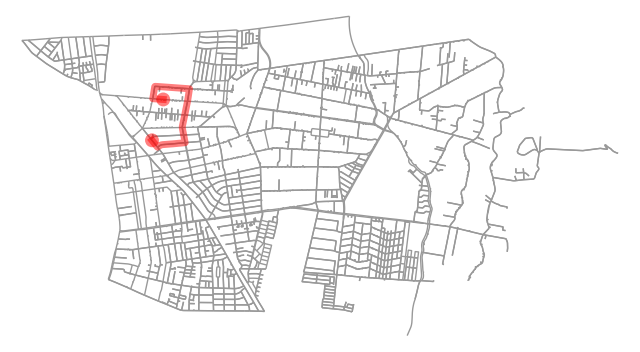

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
import osmnx as ox

print(f"The distance is: {round(distance / 1000, 2)}")

ox.plot_graph_route(
    G_final, route, route_linewidth=5, route_color="red", node_size=0, bgcolor="white"
)

In [83]:
print(G, G_final)

MultiDiGraph with 3062 nodes and 6579 edges MultiDiGraph with 3066 nodes and 6583 edges


In [85]:
G_final.nodes[1]

{'y': np.float64(-33.442338126896296), 'x': np.float64(-70.5723818547006)}

In [ ]:
import folium
import osmnx as ox

place = "La Reina, Santiago Metropolitan Region, Chile"

G = ox.graph_from_place(place, network_type="drive", simplify=True)

# centro del mapa
lat, lon = ox.geocode(place)

m = folium.Map(location=[lat, lon], zoom_start=13, tiles="OpenStreetMap")


# agregar la red
folium.GeoJson(ox.graph_to_gdfs(G, nodes=False).geometry).add_to(m)
m.save("map.html")
# m

In [ ]:
distance = nx.path_weight(G, route, weight="length")

In [127]:
G2 = nx.DiGraph()
for key, values in ss.items():
    if key[0] == key[1]:
        continue
    else:
        G2.add_edge(key[0], key[1], weight=values["distance"])

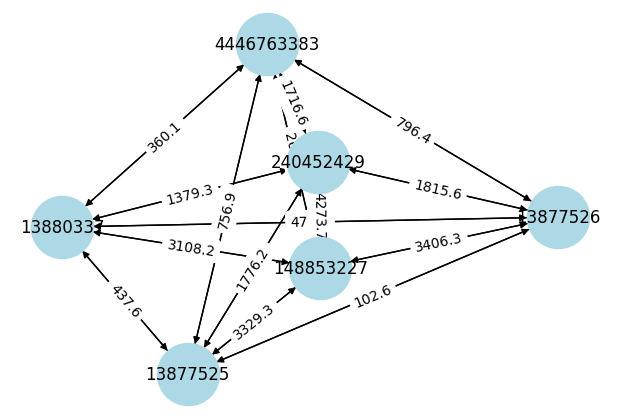

In [128]:
plt.figure(figsize=(6, 4))

pos = nx.spring_layout(G2, seed=42)

nx.draw(
    G2,
    pos,
    with_labels=True,
    node_size=2000,
    node_color="lightblue",
    arrows=True,
)

edge_labels = {(u, v): f"{d['weight']:.1f}" for u, v, d in G2.edges(data=True)}

nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.show()

In [129]:
for i in range(20000):
    u, v, k = list(G.edges(keys=True))[i]
    if G[u][v][k]["oneway"]:
        print(u, v)
        break

13877525 13877526


In [47]:
adresses = {
    "Malu": [-33.44341785083225, -70.5667162],
    "Reg_Civil": [-33.45048, -70.54276],
    "Ram_lav": [-33.44033665554887, -70.56704991349216],
}
G_final = map_point_to_closest_edge_node(G, adresses)

In [44]:
print(len(G.nodes), len(G_final.nodes))

3062 3065
